# Modelo: Regressão Logística
**Dataset:** Side-scan sonar imaging for Mine detection  
**Algoritmo:** LogisticRegression (scikit-learn)  
**Pipeline:** StandardScaler → LogisticRegression (max_iter=1000)  
**Split:** 80% treino / 20% teste | random_state=40 | stratify=y


## 1. Importações e Configuração

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    confusion_matrix, accuracy_score, classification_report,
    precision_score, recall_score, f1_score, roc_auc_score,
    roc_curve
)
import time
import tracemalloc
import platform
import psutil
import os

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120


## 2. Carregamento dos Dados

In [14]:
PATH = r"../sonar_pca_pronto22.csv"

df = pd.read_csv(PATH)
print("Shape:", df.shape)
print("\nDistribuição de classes:")
print(df.iloc[:, -1].value_counts())
df.head()


Shape: (1534, 23)

Distribuição de classes:
label
0    1303
1     231
Name: count, dtype: int64


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC14,PC15,PC16,PC17,PC18,PC19,PC20,PC21,PC22,label
0,-2.038675,6.676055,-0.710749,0.527484,-0.093916,-0.465572,-0.203055,-0.469003,-0.283768,1.407210,...,-0.412014,-0.505633,0.529430,-0.663413,-0.356119,-0.463880,0.175092,-0.424411,-0.362964,0
1,1.715479,2.147281,-1.808882,1.199814,-1.550387,-1.391381,0.078684,-1.010128,-0.331094,0.531062,...,0.210717,-0.144635,-0.014835,-0.219957,0.000575,0.058907,-0.035721,0.166862,0.030271,0
2,-1.971805,6.172167,-0.459409,-0.013397,-0.183704,-0.510791,-0.179528,-0.604994,-0.232975,1.284344,...,-0.240531,-0.687464,0.556486,0.071307,-0.604781,-0.463496,0.269669,-0.484553,-0.438719,0
3,1.651859,1.938607,-1.504424,0.681947,-1.593912,-1.468801,0.101481,-1.095702,-0.217735,0.393923,...,0.409114,-0.329197,-0.024787,0.561911,-0.196391,0.085197,0.073744,0.057167,-0.033572,0
4,-2.026155,5.795505,-0.189924,-0.710296,-0.198357,-0.324037,-0.066764,-0.606661,-0.125031,1.218323,...,-0.217793,-0.469447,0.544988,-0.622618,-0.475665,-0.674745,0.310268,-0.269451,-0.447039,0


In [15]:
import pandas as pd

# Separar as classes
classe_0 = df[df["label"] == 0]
classe_1 = df[df["label"] == 1]

# Reduzir classe majoritária
classe_0_under = classe_0.sample(
    n=len(classe_1),
    random_state=42
)

# Juntar novamente
dataset_balanceado = pd.concat([classe_0_under, classe_1])

# Embaralhar
dataset_balanceado = dataset_balanceado.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

# Verificar
print(dataset_balanceado["label"].value_counts())

df = dataset_balanceado

label
0    231
1    231
Name: count, dtype: int64


## 3. Pré-processamento

In [16]:
LABEL = df.columns[-1]
X = df.drop(columns=[LABEL])
y = df[LABEL]

le = LabelEncoder()
y = le.fit_transform(y) # M=1, R=0
X = pd.get_dummies(X, drop_first=True)
X = X.fillna(X.mean())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=40, stratify=y
)

print(f"Treino : {X_train.shape[0]} amostras  |  Teste: {X_test.shape[0]} amostras")
print(f"Classes originais : {le.classes_}  → codificadas: {le.transform(le.classes_)}")


Treino : 369 amostras  |  Teste: 93 amostras
Classes originais : [0 1]  → codificadas: [0 1]


## 4. Pipeline e Treinamento

In [17]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  LogisticRegression(max_iter=1000, random_state=40))
])

pipeline.fit(X_train, y_train)
y_pred  = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

print("Pipeline treinado (StandardScaler → LogisticRegression)")


Pipeline treinado (StandardScaler → LogisticRegression)


## 5. Métricas de Desempenho

In [18]:
acc       = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
roc_auc   = roc_auc_score(y_test, y_proba)
cv_scores = cross_val_score(pipeline, X, y, cv=5, scoring='accuracy')

metricas = {
    "Acurácia"         : acc,
    "Precisão (Mina)"  : precision,
    "Recall (Mina)"    : recall,
    "F1-Score (Mina)"  : f1,
    "ROC-AUC"          : roc_auc,
    "CV Acurácia (5x)" : cv_scores.mean(),
}

df_metricas = pd.DataFrame(metricas.items(), columns=["Métrica", "Valor"])
df_metricas["Valor"] = df_metricas["Valor"].map(lambda v: f"{v:.4f}")
print("=== MÉTRICAS – REGRESSÃO LOGÍSTICA ===")
display(df_metricas)


=== MÉTRICAS – REGRESSÃO LOGÍSTICA ===


,Métrica,Valor
0,Acurácia,0.9677
1,Precisão (Mina),0.9778
2,Recall (Mina),0.9565
3,F1-Score (Mina),0.9670
4,ROC-AUC,0.9921
5,CV Acurácia (5x),0.9371


## 6. Performance Computacional

Métricas de uso de CPU, memória RAM e tempo de execução coletadas durante o treinamento e a inferência do modelo.


In [19]:
print("=== AMBIENTE DE EXECUÇÃO ===")
print(f"  SO          : {platform.system()} {platform.release()}")
print(f"  Processador : {platform.processor() or platform.machine()}")
print(f"  Núcleos CPU : {psutil.cpu_count(logical=False)} físicos / {psutil.cpu_count()} lógicos")
print(f"  RAM total   : {psutil.virtual_memory().total / 1e9:.2f} GB")
print(f"  Python      : {platform.python_version()}")

# CPU e RAM antes do treino
cpu_antes = psutil.cpu_percent(interval=0.5)
proc      = psutil.Process(os.getpid())
ram_antes = proc.memory_info().rss / 1e6

# Treino com medição de tempo e memória 
tracemalloc.start()
t0_treino = time.perf_counter()

_pipeline_perf = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  LogisticRegression(max_iter=1000, random_state=40))
])
_pipeline_perf.fit(X_train, y_train)

t1_treino = time.perf_counter()
mem_pico_treino, _ = tracemalloc.get_traced_memory()
tracemalloc.stop()

tempo_treino       = t1_treino - t0_treino
mem_pico_treino_mb = mem_pico_treino / 1e6

# Inferência com medição de tempo 
t0_inf = time.perf_counter()
_ = _pipeline_perf.predict(X_test)
t1_inf = time.perf_counter()
tempo_inferencia  = t1_inf - t0_inf
tempo_por_amostra = tempo_inferencia / len(X_test) * 1000

# CPU e RAM depois
cpu_depois = psutil.cpu_percent(interval=0.5)
ram_depois = proc.memory_info().rss / 1e6

# Tabela de resultados
df_perf = pd.DataFrame({
    "Métrica": [
        "Tempo de Treino (s)",
        "Tempo de Inferência (s)",
        "Tempo por Amostra (ms)",
        "Pico de Memória — Treino (MB)",
        "RAM do Processo — Antes (MB)",
        "RAM do Processo — Depois (MB)",
        "Delta RAM (MB)",
        "CPU antes do treino (%)",
        "CPU depois do treino (%)",
        "Amostras de Treino",
        "Amostras de Teste",
        "Núcleos lógicos disponíveis",
    ],
    "Valor": [
        f"{tempo_treino:.6f}",
        f"{tempo_inferencia:.6f}",
        f"{tempo_por_amostra:.4f}",
        f"{mem_pico_treino_mb:.4f}",
        f"{ram_antes:.2f}",
        f"{ram_depois:.2f}",
        f"{ram_depois - ram_antes:.2f}",
        f"{cpu_antes:.1f}",
        f"{cpu_depois:.1f}",
        str(len(X_train)),
        str(len(X_test)),
        str(psutil.cpu_count()),
    ]
})

print("\n=== PERFORMANCE COMPUTACIONAL — REGRESSÃO LOGÍSTICA ===")
display(df_perf)


=== AMBIENTE DE EXECUÇÃO ===
  SO          : Windows 10
  Processador : AMD64 Family 25 Model 80 Stepping 0, AuthenticAMD
  Núcleos CPU : 6 físicos / 12 lógicos
  RAM total   : 16.53 GB
  Python      : 3.11.9

=== PERFORMANCE COMPUTACIONAL — REGRESSÃO LOGÍSTICA ===


,Métrica,Valor
0,Tempo de Treino (s),0.018318
1,Tempo de Inferência (s),0.001108
2,Tempo por Amostra (ms),0.0119
3,Pico de Memória — Treino (MB),0.0120
4,RAM do Processo — Antes (MB),255.68
5,RAM do Processo — Depois (MB),244.92
6,Delta RAM (MB),-10.76
7,CPU antes do treino (%),11.7
8,CPU depois do treino (%),7.3
9,Amostras de Treino,369


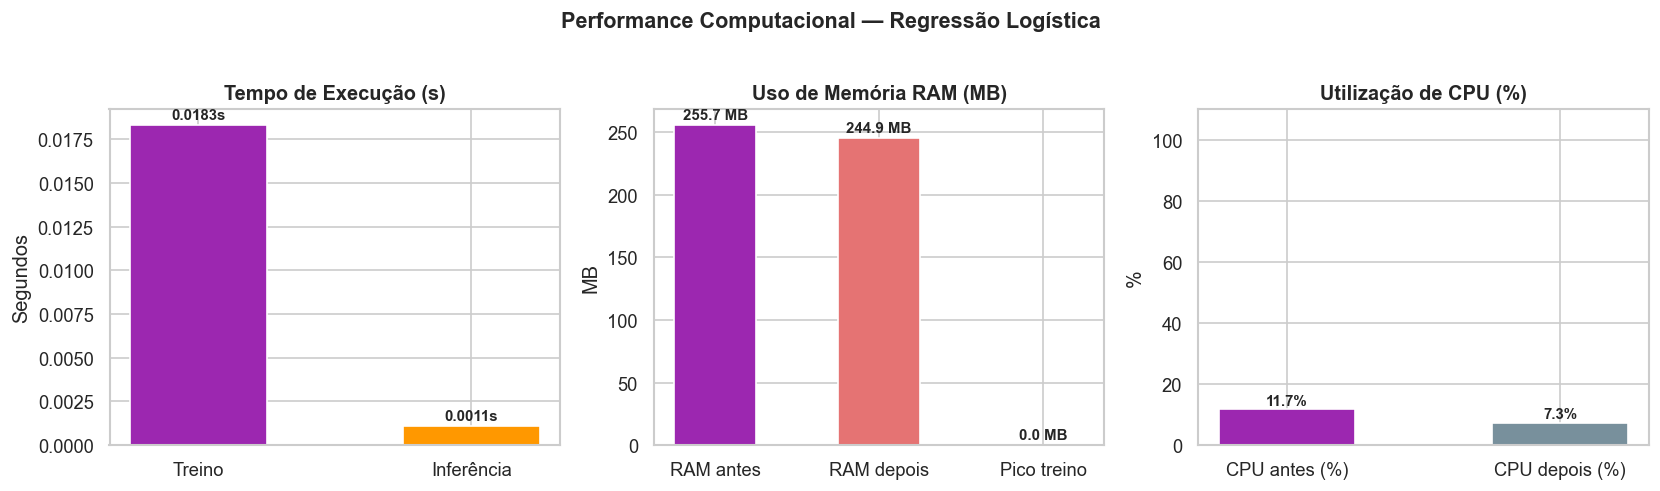

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

labels_t = ["Treino", "Inferência"]
vals_t   = [tempo_treino, tempo_inferencia]
bars = axes[0].bar(labels_t, vals_t, color=["#9C27B0", "#FF9800"], edgecolor="white", width=0.5)
for b, v in zip(bars, vals_t):
    axes[0].text(b.get_x() + b.get_width()/2, b.get_height() + max(vals_t)*0.01,
                 f"{v:.4f}s", ha="center", va="bottom", fontsize=9, fontweight="bold")
axes[0].set_title("Tempo de Execução (s)", fontweight="bold")
axes[0].set_ylabel("Segundos")

labels_m = ["RAM antes", "RAM depois", "Pico treino"]
vals_m   = [ram_antes, ram_depois, mem_pico_treino_mb]
bars = axes[1].bar(labels_m, vals_m, color=["#9C27B0", "#E57373", "#FFB74D"], edgecolor="white", width=0.5)
for b, v in zip(bars, vals_m):
    axes[1].text(b.get_x() + b.get_width()/2, b.get_height() + max(vals_m)*0.01,
                 f"{v:.1f} MB", ha="center", va="bottom", fontsize=9, fontweight="bold")
axes[1].set_title("Uso de Memória RAM (MB)", fontweight="bold")
axes[1].set_ylabel("MB")

labels_c = ["CPU antes (%)", "CPU depois (%)"]
vals_c   = [cpu_antes, cpu_depois]
bars = axes[2].bar(labels_c, vals_c, color=["#9C27B0", "#78909C"], edgecolor="white", width=0.5)
for b, v in zip(bars, vals_c):
    axes[2].text(b.get_x() + b.get_width()/2, b.get_height() + 0.5,
                 f"{v:.1f}%", ha="center", va="bottom", fontsize=9, fontweight="bold")
axes[2].set_ylim(0, 110)
axes[2].set_title("Utilização de CPU (%)", fontweight="bold")
axes[2].set_ylabel("%")

fig.suptitle("Performance Computacional — Regressão Logística", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


## 8. Matriz de Confusão

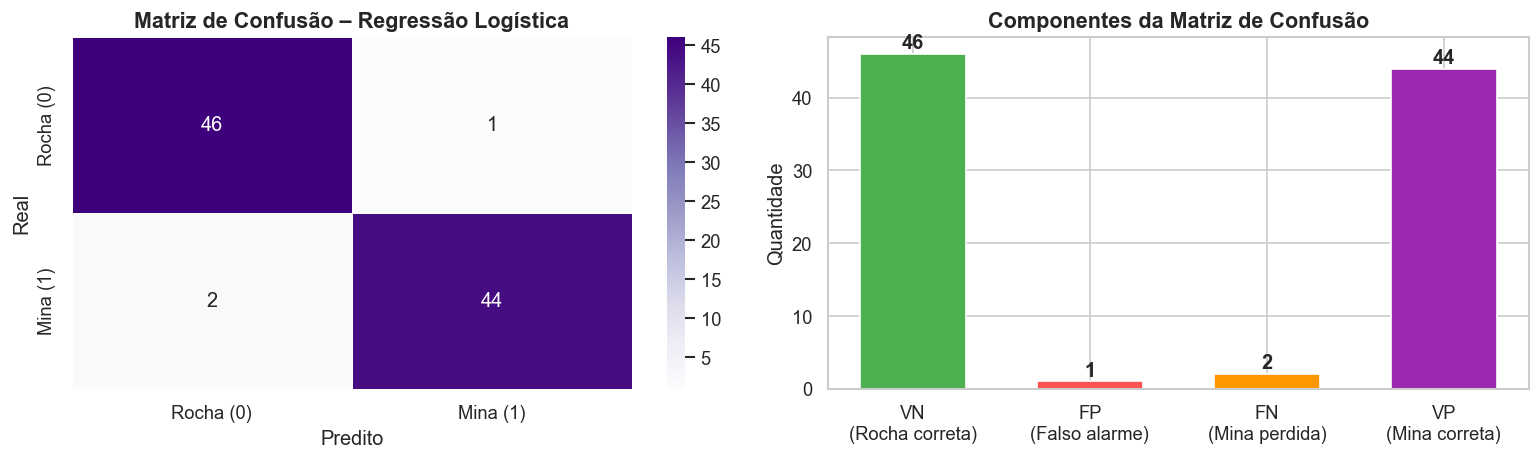


VN=46  FP=1  FN=2  VP=44


In [21]:
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Rocha (0)', 'Mina (1)'],
            yticklabels=['Rocha (0)', 'Mina (1)'],
            ax=axes[0], linewidths=.5)
axes[0].set_title('Matriz de Confusão – Regressão Logística', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Real'); axes[0].set_xlabel('Predito')

labels = ['VN\n(Rocha correta)', 'FP\n(Falso alarme)', 'FN\n(Mina perdida)', 'VP\n(Mina correta)']
values = [cm[0,0], cm[0,1], cm[1,0], cm[1,1]]
colors = ['#4CAF50', '#FF5252', '#FF9800', '#9C27B0']
bars = axes[1].bar(labels, values, color=colors, edgecolor='white', width=0.6)
for bar, val in zip(bars, values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 str(val), ha='center', va='bottom', fontweight='bold')
axes[1].set_title('Componentes da Matriz de Confusão', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Quantidade')

plt.tight_layout()
plt.savefig('../images/linear/lr_matriz_confusao.png', bbox_inches='tight')
plt.show()

print(f"\nVN={cm[0,0]}  FP={cm[0,1]}  FN={cm[1,0]}  VP={cm[1,1]}")


## 9. Curva ROC

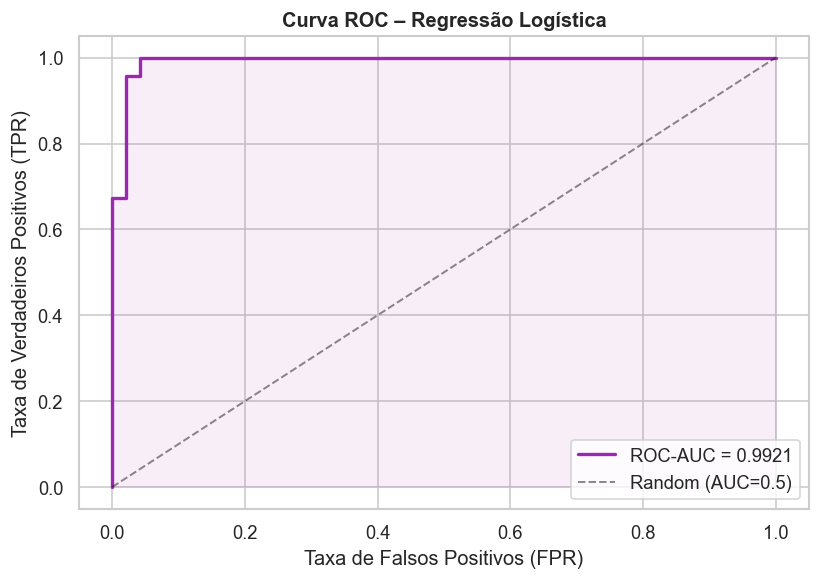

In [22]:
fpr, tpr, _ = roc_curve(y_test, y_proba)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color='#9C27B0', lw=2, label=f'ROC-AUC = {roc_auc:.4f}')
ax.plot([0,1],[0,1], 'k--', lw=1.2, alpha=0.5, label='Random (AUC=0.5)')
ax.fill_between(fpr, tpr, alpha=0.08, color='#9C27B0')
ax.set_xlabel('Taxa de Falsos Positivos (FPR)')
ax.set_ylabel('Taxa de Verdadeiros Positivos (TPR)')
ax.set_title('Curva ROC – Regressão Logística', fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../images/linear/lr_roc.png', bbox_inches='tight')
plt.show()


## 10. Relatório de Classificação

In [23]:
print(classification_report(y_test, y_pred, target_names=["Rocha (0)", "Mina (1)"]))


              precision    recall  f1-score   support

   Rocha (0)       0.96      0.98      0.97        47
    Mina (1)       0.98      0.96      0.97        46

    accuracy                           0.97        93
   macro avg       0.97      0.97      0.97        93
weighted avg       0.97      0.97      0.97        93



## 11. Validação Cruzada (5-fold)

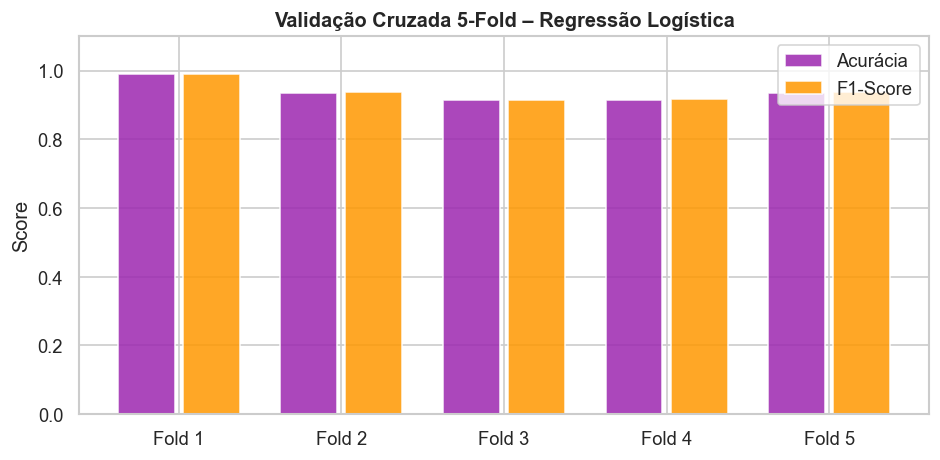

Acurácia CV → média=0.9371  std=0.0279
F1-Score CV → média=0.9390   std=0.0266


In [24]:
cv_acc = cross_val_score(pipeline, X, y, cv=5, scoring='accuracy')
cv_f1  = cross_val_score(pipeline, X, y, cv=5, scoring='f1')

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(5)
ax.bar(x - 0.2, cv_acc, 0.35, label='Acurácia', color='#9C27B0', alpha=0.85)
ax.bar(x + 0.2, cv_f1,  0.35, label='F1-Score',  color='#FF9800', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels([f'Fold {i+1}' for i in range(5)])
ax.set_ylim(0, 1.1); ax.set_ylabel('Score')
ax.set_title('Validação Cruzada 5-Fold – Regressão Logística', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../images/linear/lr_cv.png', bbox_inches='tight')
plt.show()

print(f"Acurácia CV → média={cv_acc.mean():.4f}  std={cv_acc.std():.4f}")
print(f"F1-Score CV → média={cv_f1.mean():.4f}   std={cv_f1.std():.4f}")


## 12. Sumário Final

In [25]:
resultados_modelo = pd.DataFrame({
    "Modelo"          : ["Regressão Linear"],
    "Acurácia"        : [round(acc, 4)],
    "Precisão"        : [round(precision, 4)],
    "Recall"          : [round(recall, 4)],
    "F1-Score"        : [round(f1, 4)],
    "ROC-AUC"         : [round(roc_auc, 4)],
    "CV Acurácia (μ)" : [round(cv_scores.mean(), 4)],
})

dados_processamento = pd.DataFrame({
    "Tempo Treino (s)"         : [round(tempo_treino, 6)],
    "Tempo Inferência (s)"     : [round(tempo_inferencia, 6)],
    "Tempo/Amostra (ms)"       : [round(tempo_por_amostra, 4)],
    "Pico Memória Treino (MB)" : [round(mem_pico_treino_mb, 4)],
    "Delta RAM (MB)"           : [round(ram_depois - ram_antes, 2)],
})

print("=== RESULTADOS DO MODELO ===")
display(resultados_modelo)

print("=== DADOS DE PROCESSAMENTO ===")
display(dados_processamento)

resultados_modelo.to_csv("../results/linear/resultados_modelo_linear.csv", index=False)
dados_processamento.to_csv("../results/linear/dados_processamento_linear.csv", index=False)

print("Arquivos CSV gerados com sucesso!")


=== RESULTADOS DO MODELO ===


,Modelo,Acurácia,Precisão,Recall,F1-Score,ROC-AUC,CV Acurácia (μ)
0,Regressão Linear,0.9677,0.9778,0.9565,0.967,0.9921,0.9371


=== DADOS DE PROCESSAMENTO ===


,Tempo Treino (s),Tempo Inferência (s),Tempo/Amostra (ms),Pico Memória Treino (MB),Delta RAM (MB)
0,0.018318,0.001108,0.0119,0.012,-10.76


Arquivos CSV gerados com sucesso!
